<a href="https://colab.research.google.com/github/Parastoo-kh/MultiObjective-Model-Solved-By-NSGA-III--Constraint/blob/main/OptimizationModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 19.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

Generating realistic dataset...
Dataset generation completed.

Solving baseline models...

Minimum Cost Model Solved.
Maximum Satisfaction Model Solved.
Minimum Workload Imbalance Model Solved.

BASELINE RESULTS

Minimum Cost:
30300.0

Maximum Satisfaction:
593.95

Minimum Workload Imbalance:
0.0

Running epsilon-constraint optimization...

Solving epsilon = 530.55
Solving epsilon = 536.31
Solving epsilon = 542.08
Solving epsilon = 547.84
Solving epsilon = 553.6
Solving epsilon = 559.37
Solving epsilon = 565.13
Solving epsilon = 570.9
Solving epsilon = 576.66
Solving epsilon = 582.42
Solving epsilon = 588.19
Solving epsilon = 593.95


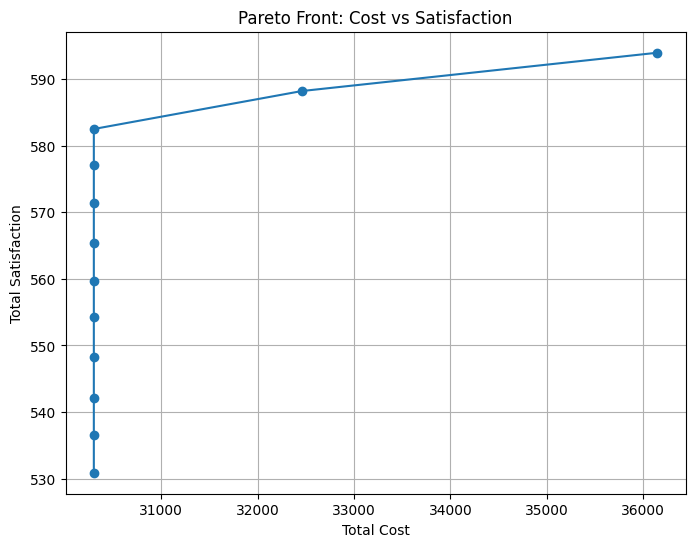

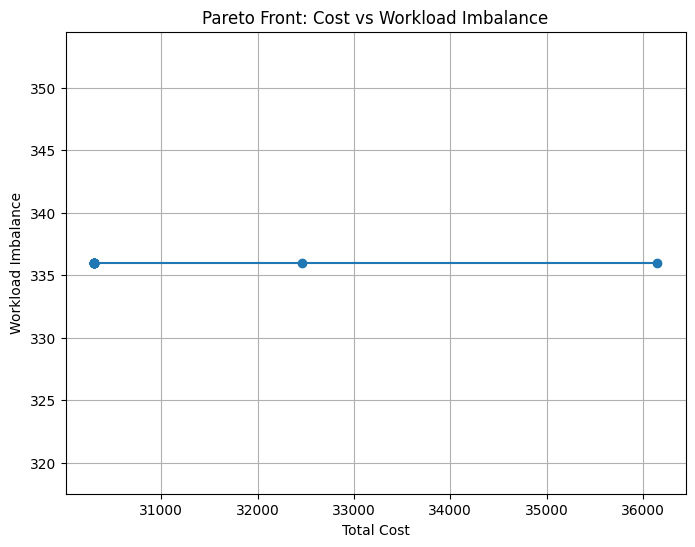

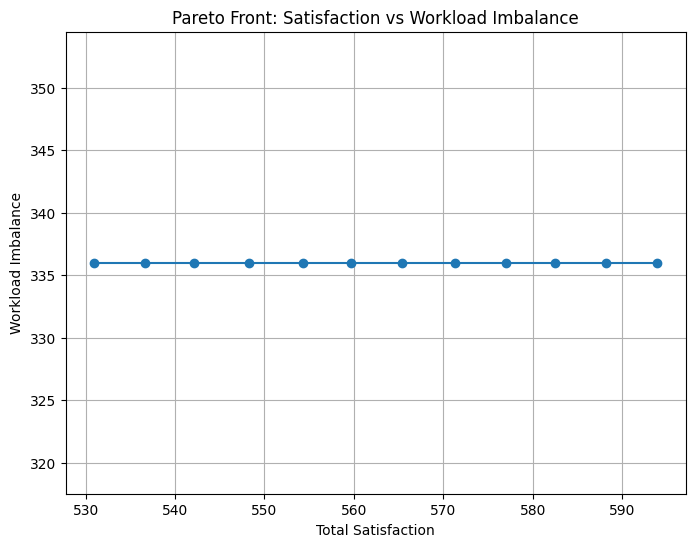


ALL RESULTS GENERATED SUCCESSFULLY

Generated Files:
- nurse_skills.xlsx
- pareto_results.xlsx
- final_schedule.xlsx

Optimization completed successfully.


In [ ]:
# ======================================================================
# FULL NURSE SCHEDULING OPTIMIZATION MODEL
# ======================================================================
# Multi-Objective Nurse Scheduling Problem
# Solution Method: ε-Constraint
# Solver: OR-Tools SCIP
# ======================================================================
# OBJECTIVES:
#
# Z1 -> Minimize Total Cost
# Z2 -> Maximize Nurse Satisfaction
# Z3 -> Minimize Workload Imbalance
#
# ======================================================================
# FEATURES:
#
# ✔ Realistic synthetic dataset generation
# ✔ Skill-based scheduling
# ✔ Overtime modeling
# ✔ Workload fairness
# ✔ Satisfaction modeling
# ✔ ε-constraint Pareto generation
# ✔ Excel exports
# ✔ Pareto visualization
# ✔ Feasibility-safe formulation
#
# ======================================================================



# ======================================================================
# INSTALL REQUIRED LIBRARIES (RUN ONLY ONCE IN GOOGLE COLAB)
# ======================================================================

!pip install ortools pandas numpy matplotlib openpyxl



# ======================================================================
# IMPORT LIBRARIES
# ======================================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ortools.linear_solver import pywraplp



# ======================================================================
# RANDOM SEED
# ======================================================================

random.seed(42)
np.random.seed(42)



# ======================================================================
# BASIC PARAMETERS
# ======================================================================

NUM_NURSES = 30
NUM_DAYS = 14

NURSES = [f"N{i+1:02d}" for i in range(NUM_NURSES)]

DAYS = [f"D{d+1:02d}" for d in range(NUM_DAYS)]

SHIFTS = ["Day", "Evening", "Night"]

WEEKENDS = ["D06", "D07", "D13", "D14"]



# ======================================================================
# SHIFT HOURS
# ======================================================================

SHIFT_HOURS = {

    "Day": 8,
    "Evening": 8,
    "Night": 8
}



# ======================================================================
# SHIFT COSTS
# ======================================================================

SHIFT_COST = {

    "Day": 100,
    "Evening": 120,
    "Night": 150
}



# ======================================================================
# OVERTIME PARAMETERS
# ======================================================================

MAX_REGULAR_HOURS = 80

OVERTIME_COST = 35



# ======================================================================
# SATISFACTION WEIGHTS
# (Temporary values before questionnaire analysis)
# ======================================================================

w1 = 0.30
w2 = 0.25
w3 = 0.20
w4 = 0.25



# ======================================================================
# ======================================================================
# DATASET GENERATION
# ======================================================================
# ======================================================================

print("Generating realistic dataset...")


# ======================================================================
# NURSE SKILL MATRIX
# ======================================================================

skills_df = pd.DataFrame(
    0,
    index=NURSES,
    columns=["ICU", "Emergency"]
)

# ICU Nurses
icu_nurses = random.sample(NURSES, 10)

for n in icu_nurses:
    skills_df.loc[n, "ICU"] = 1

# Emergency Nurses
emergency_nurses = random.sample(NURSES, 8)

for n in emergency_nurses:
    skills_df.loc[n, "Emergency"] = 1



# ======================================================================
# PREFERRED SHIFTS
# ======================================================================

preferred_shift = {}

for n in NURSES:

    preferred_shift[n] = random.choice(SHIFTS)



# ======================================================================
# REQUESTED DAYS OFF
# ======================================================================

requested_off = {}

for n in NURSES:

    requested_off[n] = random.sample(DAYS, 2)



# ======================================================================
# DAILY SHIFT DEMANDS
# ======================================================================

total_demand = {}

icu_demand = {}

emergency_demand = {}

for d in DAYS:

    for s in SHIFTS:

        # --------------------------------------------------------------
        # Base staffing demand
        # --------------------------------------------------------------

        if s == "Day":
            base = 8

        elif s == "Evening":
            base = 6

        else:
            base = 5

        # --------------------------------------------------------------
        # Weekend reduction
        # --------------------------------------------------------------

        if d in WEEKENDS:
            base -= 1

        total_demand[(d, s)] = base

        # --------------------------------------------------------------
        # ICU requirement
        # --------------------------------------------------------------

        if s == "Day":
            icu_demand[(d, s)] = 2
        else:
            icu_demand[(d, s)] = 1

        # --------------------------------------------------------------
        # Emergency requirement
        # --------------------------------------------------------------

        emergency_demand[(d, s)] = 1



# ======================================================================
# SAVE GENERATED DATASETS
# ======================================================================

skills_df.to_excel("nurse_skills.xlsx")

print("Dataset generation completed.")



# ======================================================================
# ======================================================================
# SOLVER FUNCTION
# ======================================================================
# ======================================================================

def solve_model(
        objective="cost",
        epsilon_satisfaction=None
):

    # ==================================================================
    # CREATE SOLVER
    # ==================================================================

    solver = pywraplp.Solver.CreateSolver("SCIP")

    if not solver:
        print("SCIP solver not found.")
        return None



    # ==================================================================
    # DECISION VARIABLES
    # ==================================================================

    x = {}

    for i in NURSES:

        for d in DAYS:

            for s in SHIFTS:

                x[(i, d, s)] = solver.IntVar(
                    0,
                    1,
                    f"x_{i}_{d}_{s}"
                )



    # ==================================================================
    # OVERTIME VARIABLES
    # ==================================================================

    overtime = {}

    for i in NURSES:

        overtime[i] = solver.NumVar(
            0,
            solver.infinity(),
            f"OT_{i}"
        )



    # ==================================================================
    # WORKLOAD VARIABLES
    # ==================================================================

    workload = {}

    for i in NURSES:

        workload[i] = solver.NumVar(
            0,
            solver.infinity(),
            f"W_{i}"
        )



    # ==================================================================
    # AVERAGE WORKLOAD
# ==================================================================

    avg_workload = solver.NumVar(
        0,
        solver.infinity(),
        "Average_Workload"
    )



    # ==================================================================
    # WORKLOAD IMBALANCE VARIABLE
# ==================================================================

    WI = solver.NumVar(
        0,
        solver.infinity(),
        "Workload_Imbalance"
    )



    # ==================================================================
    # WORKLOAD CALCULATIONS
# ==================================================================

    for i in NURSES:

        total_hours = solver.Sum(

            SHIFT_HOURS[s] * x[(i, d, s)]

            for d in DAYS
            for s in SHIFTS
        )

        solver.Add(
            workload[i] == total_hours
        )



    # ==================================================================
    # AVERAGE WORKLOAD
# ==================================================================

    solver.Add(

        avg_workload * NUM_NURSES ==

        solver.Sum(
            workload[i]
            for i in NURSES
        )
    )



    # ==================================================================
    # WORKLOAD IMBALANCE CONSTRAINTS
# ==================================================================

    for i in NURSES:

        solver.Add(
            WI >= workload[i] - avg_workload
        )

        solver.Add(
            WI >= avg_workload - workload[i]
        )



    # ==================================================================
    # SATISFACTION FUNCTIONS
# ==================================================================

    # ------------------------------------------------------------------
    # f1 = Preferred Shift Satisfaction
    # ------------------------------------------------------------------

    f1 = solver.Sum(

        x[(i, d, s)]

        for i in NURSES
        for d in DAYS
        for s in SHIFTS

        if s == preferred_shift[i]
    )



    # ------------------------------------------------------------------
    # f2 = Weekend-Off Satisfaction
    # ------------------------------------------------------------------

    f2_terms = []

    for i in NURSES:

        for d in WEEKENDS:

            f2_terms.append(

                1 -

                solver.Sum(
                    x[(i, d, s)]
                    for s in SHIFTS
                )
            )

    f2 = solver.Sum(f2_terms)



    # ------------------------------------------------------------------
    # f3 = Overtime Satisfaction
    # ------------------------------------------------------------------

    f3 = solver.Sum(

        MAX_REGULAR_HOURS - overtime[i]

        for i in NURSES
    )



    # ------------------------------------------------------------------
    # f4 = Requested-Off Satisfaction
    # ------------------------------------------------------------------

    f4_terms = []

    for i in NURSES:

        for d in requested_off[i]:

            f4_terms.append(

                1 -

                solver.Sum(
                    x[(i, d, s)]
                    for s in SHIFTS
                )
            )

    f4 = solver.Sum(f4_terms)



    # ==================================================================
    # TOTAL SATISFACTION FUNCTION
# ==================================================================

    total_satisfaction = (

            w1 * f1 +
            w2 * f2 +
            w3 * f3 +
            w4 * f4
    )



    # ==================================================================
    # TOTAL COST FUNCTION
# ==================================================================

    total_cost = solver.Sum(

        SHIFT_COST[s] * x[(i, d, s)]

        for i in NURSES
        for d in DAYS
        for s in SHIFTS

    ) + solver.Sum(

        OVERTIME_COST * overtime[i]

        for i in NURSES
    )



    # ==================================================================
    # EPSILON CONSTRAINT
# ==================================================================

    if epsilon_satisfaction is not None:

        solver.Add(
            total_satisfaction >= epsilon_satisfaction
        )



    # ==================================================================
    # CONSTRAINT 1
    # ONE SHIFT PER DAY
    # ==================================================================

    for i in NURSES:

        for d in DAYS:

            solver.Add(

                solver.Sum(
                    x[(i, d, s)]
                    for s in SHIFTS
                ) <= 1
            )



    # ==================================================================
    # CONSTRAINT 2
    # TOTAL SHIFT COVERAGE
    # ==================================================================

    for d in DAYS:

        for s in SHIFTS:

            solver.Add(

                solver.Sum(

                    x[(i, d, s)]

                    for i in NURSES

                ) >= total_demand[(d, s)]
            )



    # ==================================================================
    # CONSTRAINT 3
    # ICU COVERAGE
    # ==================================================================

    for d in DAYS:

        for s in SHIFTS:

            solver.Add(

                solver.Sum(

                    x[(i, d, s)]

                    for i in NURSES

                    if skills_df.loc[i, "ICU"] == 1

                ) >= icu_demand[(d, s)]
            )



    # ==================================================================
    # CONSTRAINT 4
    # EMERGENCY COVERAGE
    # ==================================================================

    for d in DAYS:

        for s in SHIFTS:

            solver.Add(

                solver.Sum(

                    x[(i, d, s)]

                    for i in NURSES

                    if skills_df.loc[i, "Emergency"] == 1

                ) >= emergency_demand[(d, s)]
            )



    # ==================================================================
    # CONSTRAINT 5
    # MAXIMUM HOURS + OVERTIME
    # ==================================================================

    for i in NURSES:

        total_hours = solver.Sum(

            SHIFT_HOURS[s] * x[(i, d, s)]

            for d in DAYS
            for s in SHIFTS
        )

        solver.Add(

            total_hours <=

            MAX_REGULAR_HOURS + overtime[i]
        )



    # ==================================================================
    # CONSTRAINT 6
    # NO NIGHT -> DAY TRANSITION
    # ==================================================================

    for i in NURSES:

        for d in range(NUM_DAYS - 1):

            current_day = DAYS[d]

            next_day = DAYS[d + 1]

            solver.Add(

                x[(i, current_day, "Night")] +

                x[(i, next_day, "Day")]

                <= 1
            )



    # ==================================================================
    # CONSTRAINT 7
    # MAXIMUM CONSECUTIVE NIGHT SHIFTS
    # ==================================================================

    for i in NURSES:

        for d in range(NUM_DAYS - 2):

            d1 = DAYS[d]
            d2 = DAYS[d + 1]
            d3 = DAYS[d + 2]

            solver.Add(

                x[(i, d1, "Night")] +

                x[(i, d2, "Night")] +

                x[(i, d3, "Night")]

                <= 2
            )



    # ==================================================================
    # OBJECTIVE SELECTION
    # ==================================================================

    if objective == "cost":

        solver.Minimize(total_cost)

    elif objective == "satisfaction":

        solver.Maximize(total_satisfaction)

    elif objective == "workload":

        solver.Minimize(WI)



    # ==================================================================
    # SOLVE MODEL
    # ==================================================================

    status = solver.Solve()



    # ==================================================================
    # CHECK FEASIBILITY
    # ==================================================================

    if status != pywraplp.Solver.OPTIMAL:

        print("No feasible solution found.")

        return None



    # ==================================================================
    # BUILD SCHEDULE TABLE
    # ==================================================================

    schedule = []

    for i in NURSES:

        row = [i]

        for d in DAYS:

            assigned = "Off"

            for s in SHIFTS:

                if x[(i, d, s)].solution_value() > 0.5:

                    assigned = s

            row.append(assigned)

        schedule.append(row)



    schedule_df = pd.DataFrame(

        schedule,

        columns=["Nurse"] + DAYS
    )



    # ==================================================================
    # RETURN RESULTS
    # ==================================================================

    return {

        "Cost": total_cost.solution_value(),

        "Satisfaction": total_satisfaction.solution_value(),

        "WorkloadImbalance": WI.solution_value(),

        "Schedule": schedule_df
    }



# ======================================================================
# ======================================================================
# BASELINE SOLUTIONS
# ======================================================================
# ======================================================================

print("\nSolving baseline models...\n")


# ======================================================================
# MINIMUM COST
# ======================================================================

min_cost_solution = solve_model(
    objective="cost"
)

print("Minimum Cost Model Solved.")


# ======================================================================
# MAXIMUM SATISFACTION
# ======================================================================

max_satisfaction_solution = solve_model(
    objective="satisfaction"
)

print("Maximum Satisfaction Model Solved.")


# ======================================================================
# MINIMUM WORKLOAD IMBALANCE
# ======================================================================

min_workload_solution = solve_model(
    objective="workload"
)

print("Minimum Workload Imbalance Model Solved.")



# ======================================================================
# PRINT BASELINE RESULTS
# ======================================================================

print("\n=================================================")
print("BASELINE RESULTS")
print("=================================================")

print("\nMinimum Cost:")
print(min_cost_solution["Cost"])

print("\nMaximum Satisfaction:")
print(max_satisfaction_solution["Satisfaction"])

print("\nMinimum Workload Imbalance:")
print(min_workload_solution["WorkloadImbalance"])



# ======================================================================
# ======================================================================
# EPSILON-CONSTRAINT METHOD
# ======================================================================
# ======================================================================

print("\nRunning epsilon-constraint optimization...\n")


# ======================================================================
# EPSILON RANGE
# ======================================================================

min_sat = min_cost_solution["Satisfaction"]

max_sat = max_satisfaction_solution["Satisfaction"]

epsilon_values = np.linspace(
    min_sat,
    max_sat,
    12
)



# ======================================================================
# STORE PARETO RESULTS
# ======================================================================

pareto_results = []



# ======================================================================
# EPSILON LOOP
# ======================================================================

for eps in epsilon_values:

    print(f"Solving epsilon = {round(eps,2)}")

    result = solve_model(
        objective="cost",
        epsilon_satisfaction=eps
    )

    if result is not None:

        pareto_results.append([

            result["Cost"],

            result["Satisfaction"],

            result["WorkloadImbalance"]
        ])



# ======================================================================
# PARETO DATAFRAME
# ======================================================================

pareto_df = pd.DataFrame(

    pareto_results,

    columns=[
        "Cost",
        "Satisfaction",
        "WorkloadImbalance"
    ]
)



# ======================================================================
# SAVE RESULTS
# ======================================================================

pareto_df.to_excel(
    "pareto_results.xlsx",
    index=False
)

min_cost_solution["Schedule"].to_excel(
    "final_schedule.xlsx",
    index=False
)



# ======================================================================
# ======================================================================
# VISUALIZATION
# ======================================================================
# ======================================================================


# ======================================================================
# PARETO FRONT: COST vs SATISFACTION
# ======================================================================

plt.figure(figsize=(8,6))

# Sort by Satisfaction for a clearer Pareto front, then by Cost
plot_df_cs = pareto_df.sort_values(by=['Satisfaction', 'Cost'])
plt.plot(

    plot_df_cs["Cost"],

    plot_df_cs["Satisfaction"],

    marker='o'
)

plt.xlabel("Total Cost")

plt.ylabel("Total Satisfaction")

plt.title("Pareto Front: Cost vs Satisfaction")

plt.grid(True)

plt.show()



# ======================================================================
# PARETO FRONT: COST vs WORKLOAD IMBALANCE
# ======================================================================

plt.figure(figsize=(8,6))

# Sort by WorkloadImbalance for a clearer Pareto front, then by Cost
plot_df_cwi = pareto_df.sort_values(by=['WorkloadImbalance', 'Cost'])
plt.plot(

    plot_df_cwi["Cost"],

    plot_df_cwi["WorkloadImbalance"],

    marker='o'
)

plt.xlabel("Total Cost")

plt.ylabel("Workload Imbalance")

plt.title("Pareto Front: Cost vs Workload Imbalance")

plt.grid(True)

plt.show()



# ======================================================================
# PARETO FRONT: SATISFACTION vs WORKLOAD IMBALANCE
# ======================================================================

plt.figure(figsize=(8,6))

# Sort by Satisfaction for a clearer Pareto front, then by WorkloadImbalance
plot_df_swi = pareto_df.sort_values(by=['Satisfaction', 'WorkloadImbalance'])
plt.plot(

    plot_df_swi["Satisfaction"],

    plot_df_swi["WorkloadImbalance"],

    marker='o'
)

plt.xlabel("Total Satisfaction")

plt.ylabel("Workload Imbalance")

plt.title("Pareto Front: Satisfaction vs Workload Imbalance")

plt.grid(True)

plt.show()



# ======================================================================
# FINAL MESSAGE
# ======================================================================

print("\n=================================================")
print("ALL RESULTS GENERATED SUCCESSFULLY")
print("=================================================")

print("\nGenerated Files:")
print("- nurse_skills.xlsx")
print("- pareto_results.xlsx")
print("- final_schedule.xlsx")

print("\nOptimization completed successfully.")